# Programming Assignment 3 - Scalable Clustering Techniques

In [10]:
# imports for the whole homework
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import time
from sklearn.metrics import normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

In [11]:
def load_covertype(file_path=r"./datasets/covtype.data.gz"):
    """
    Loads the Covertype dataset from a gzipped CSV-like file.
    Default path is relative to the current directory.
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Dataset not found at {file_path}. Please check the directory path.")

    print("Loading Covertype dataset")
    
    df = pd.read_csv(file_path, header=None, compression='gzip')
    
    X = df.iloc[:, :-1].values.astype(np.float32)
    
    # last column is the ground truth forest cover type (labels 1 through 7)
    y = df.iloc[:, -1].values.astype(np.int32)
    
    print(f"Dataset Loaded Successfully.")
    print(f"Instances: {X.shape[0]}, Features: {X.shape[1]}, Classes: {len(np.unique(y))}")
    
    return X, y

## 1. Lloyd’s algorithm for k-Means Clustering

As a baseline model implement
Lloyd’s algorithm [4] for k-means clustering and initialize it with the first k points as
initial cluster centers. The default convergence criteria is to stop the algorithm if none
of the cluster memberships have changed in comparison to the previous iteration.

□ Include a plot illustrating convergence of k-means.

□ Track the number of iterations needed for convergence and compare it to the other
implementations.

□ Report the achieved NMI averaged over at least 5 runs.

□ Report the runtime in [sec] for your algorithm averaged over at least 5 runs. Also
report the number of distance computations performed.

□ Briefly discuss your implementation of Lloyds algorithm.

In [12]:
def lloyds_algorithm(X, k, y_true, max_iter=100):
    """
    Implementation of Lloyd's algorithm as seen in slide 9 of Unsupervised handout.
    """
    # initialization
    # mu_j^(0) = first k points of X
    mu = X[:k, :].copy()
    
    n_samples = X.shape[0]
    z = np.zeros(n_samples, dtype=int) # cluster memberships
    history_sq_dist = []
    
    start_time = time.time()

    for t in range(1, max_iter + 1):
        # cluster assignments (z_i^(t))
        # equation: z_i^(t) = argmin ||x_i - mu_j^(t-1)||_2^2
        # optimized calculation for large datasets:
        x_sq = np.sum(X**2, axis=1, keepdims=True)
        mu_sq = np.sum(mu**2, axis=1)
        distances_sq = x_sq + mu_sq - 2 * np.dot(X, mu.T)
        
        new_z = np.argmin(distances_sq, axis=1)
        
        # track the sum of squared distances for the convergence plot
        inertia = np.sum(np.min(distances_sq, axis=1))
        history_sq_dist.append(inertia)

        # convergence criteria - stop if none of the cluster memberships (z) have changed
        if np.array_equal(new_z, z):
            print(f"Converged at iteration {t}")
            break
        z = new_z.copy()

        # update cluster centers (mu_j^(t))
        # equation: mu_j^(t) = (1/n_j) * sum(x_i) for x_i assigned to j
        for j in range(k):
            assigned_points = X[z == j]
            if len(assigned_points) > 0:
                mu[j] = np.mean(assigned_points, axis=0)
            # if a cluster is empty, mu[j] remains the same (as per slide logic)

    runtime = time.time() - start_time
    
    nmi = normalized_mutual_info_score(y_true, z, average_method='arithmetic')
    
    return nmi, t, history_sq_dist, runtime

In [17]:
def run_experiment(X_raw, y_raw, k_values=[7, 30], num_runs=5):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    final_report = {}

    for k in k_values:
        run_nmis = []
        run_iters = []
        run_times = []
        
        print(f"\nEvaluating Lloyd's Algorithm for k={k}...")
        
        for r in range(num_runs):
            # shuffle data so "first k" points vary between runs for averaging
            X_s, y_s = shuffle(X_scaled, y_raw, random_state=r)
            
            nmi, iters, history, duration = lloyds_algorithm(X_s, k, y_s)
            
            run_nmis.append(nmi)
            run_iters.append(iters)
            run_times.append(duration)
            
            if r == num_runs-1:
                # plot illustrating convergence
                plt.figure(figsize=(7, 4))
                plt.plot(range(1, len(history) + 1), history, marker='x', color='tab:orange')
                plt.title(f"Lloyd's Convergence (k={k}, Run {r+1})")
                plt.xlabel("Iteration (t)")
                plt.ylabel("Total Squared Distance")
                plt.grid(True)
                plt.show()

        print(f"k={k} Average Results ({num_runs} runs):")
        print(f" - NMI: {np.mean(run_nmis):.4f}")
        print(f" - Iterations: {np.mean(run_iters):.1f}")
        print(f" - Runtime: {np.mean(run_times):.2f}s")
        
        final_report[k] = {"nmi": np.mean(run_nmis), "iters": np.mean(run_iters)}
        
    return final_report

Loading Covertype dataset
Dataset Loaded Successfully.
Instances: 581012, Features: 54, Classes: 7

Evaluating Lloyd's Algorithm for k=7...
Converged at iteration 19
Converged at iteration 22
Converged at iteration 24
Converged at iteration 35
Converged at iteration 32


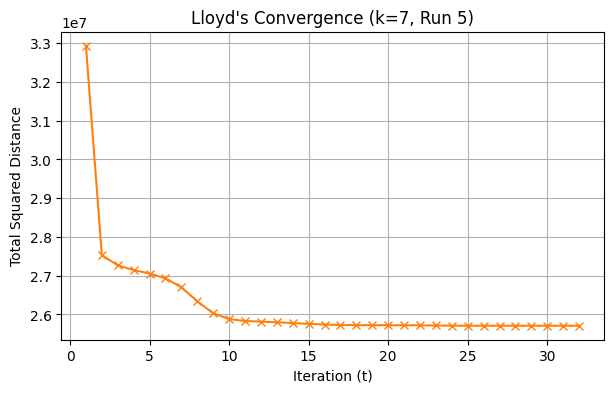

k=7 Average Results (5 runs):
 - NMI: 0.1611
 - Iterations: 26.4
 - Runtime: 5.18s

Evaluating Lloyd's Algorithm for k=30...
Converged at iteration 28
Converged at iteration 86
Converged at iteration 55
Converged at iteration 31
Converged at iteration 29


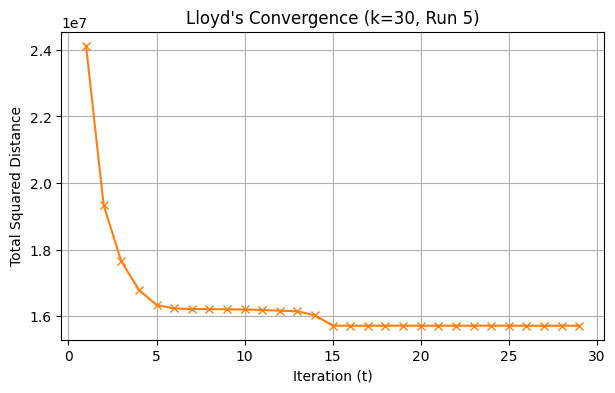

k=30 Average Results (5 runs):
 - NMI: 0.1784
 - Iterations: 45.8
 - Runtime: 14.81s

Final Report:
k=7: NMI=0.1611, Avg Iterations=26.4
k=30: NMI=0.1784, Avg Iterations=45.8


In [19]:
X, y = load_covertype()
result = run_experiment(X, y)
print("\nFinal Report:")
for k, metrics in result.items():
    print(f"k={k}: NMI={metrics['nmi']:.4f}, Avg Iterations={metrics['iters']:.1f}")

## 2. k-Means with Locality Sensitive Hashing (LSH)

Implement Lloyd’s algorithm using LSH to speed up the distance calculations. See the uploaded presentation
on Moodle on how LSH should be used.
Try out different settings in which you combine different hash functions with AND and
OR as it was discussed in the lecture. For example, you can have one setting where
you combine two hash functions with AND and in the second setting you combine two
functions with OR, but you could try out several combinations, with different hash
functions. Also try varying the number of buckets of your hashing function. Measure
the runtime timeLSH of your LSH implementation.

□ Report how you selected the parameters of LSH and how you combined your functions.

□ Report the accuracy using NMI and the runtime in seconds averaged over at least 5
runs. Also report the number of distance computations performed. If your implementa
tion doesn’t show a speed-up, discuss why this might be and also discuss whether this situation would change when working larger datasets.

□ Track the number of iterations needed for convergence (if it converges at all) and
compare it to the other implementations.

□ Briefly discuss your implementation of k-means with LSH.

## 3. k-means with coresets

Coresets are a compact representation of data sets,
such that models trained on a coreset are competitive with models trained on the full
dataset [3, 1]. In this task you will implement coresets for k-means clustering as in [1,
Algorithm 1]. For the the number of samples m, use 100, 1000, and 10000.

□ Report the runtime and NMI you achieve when using coresets of different size (as
described above) averaged over at least 5 runs. To do so, cluster the coresets using
sklearn’s k-means algorithm (you can supply sample weights to all needed functions).

□ Track the number of iterations needed for convergence and compare it to the other
implementations.

□ Analyze the variance of the accuracy obtained when using coresets for clustering by
computing 10 coresets for each choice of m.

## Report

Write a report about your work on this assignment, your findings and results. Make
sure to report all the information indicated above. Additionally report the following:

□ Show the performance in terms of NMI and runtime for the different approaches in
one plot or table.